# Week 3 — Applied AI

## Task 3.1 — TensorFlow/Keras Neural Network

### Objective
Build and train a neural network using TensorFlow/Keras
and compare its performance with the previous PyTorch model.

## 1. Task Overview

In this task, I will build a neural network using TensorFlow/Keras.

The main steps are:

1. Prepare the dataset
2. Split the data into training and testing sets
3. Build a neural network using Keras
4. Compile the model
5. Train the model
6. Evaluate its performance
7. Compare the results with the previous PyTorch model

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
data = {
    "Hours_Studied": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9],
    "Attendance": [50, 55, 60, 65, 70, 68, 75, 72, 80, 78, 85, 82, 88, 90, 94, 96],
    "Passed": [0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

df

,Hours_Studied,Attendance,Passed
0,1,50,0
1,2,55,0
2,2,60,0
3,3,65,0
4,3,70,1
5,4,68,0
6,4,75,1
7,5,72,1
8,5,80,1
9,6,78,1


In [ ]:
X = df[["Hours_Studied", "Attendance"]]
y = df["Passed"]

print("Features:")
print(X)

print("\nTarget:")
print(y)


Features:
    Hours_Studied  Attendance
0               1          50
1               2          55
2               2          60
3               3          65
4               3          70
5               4          68
6               4          75
7               5          72
8               5          80
9               6          78
10              6          85
11              7          82
12              7          88
13              8          90
14              8          94
15              9          96

Target:
0     0
1     0
2     0
3     0
4     1
5     0
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: Passed, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 12
Testing samples: 4


In [ ]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print(X_train.shape)
print(y_train.shape)

(12, 2)
(12,)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.6667 - loss: 3.4217 - val_accuracy: 0.6667 - val_loss: 3.4520
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6667 - loss: 3.3029 - val_accuracy: 0.6667 - val_loss: 3.3407
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6667 - loss: 3.1890 - val_accuracy: 0.6667 - val_loss: 3.2309
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6667 - loss: 3.0663 - val_accuracy: 0.6667 - val_loss: 3.1268
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6667 - loss: 2.9875 - val_accuracy: 0.6667 - val_loss: 3.0231
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6667 - loss: 2.9110 - val_accuracy: 0.6667 - val_loss: 2.9298
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6667 - loss: 2.7895 - val_accuracy: 0.6667 - val_loss: 2.8472
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6667 - loss: 2.7068 - val_accuracy: 0.6667 - val_loss: 2.7595

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.5059249401092529
Test Accuracy: 0.75


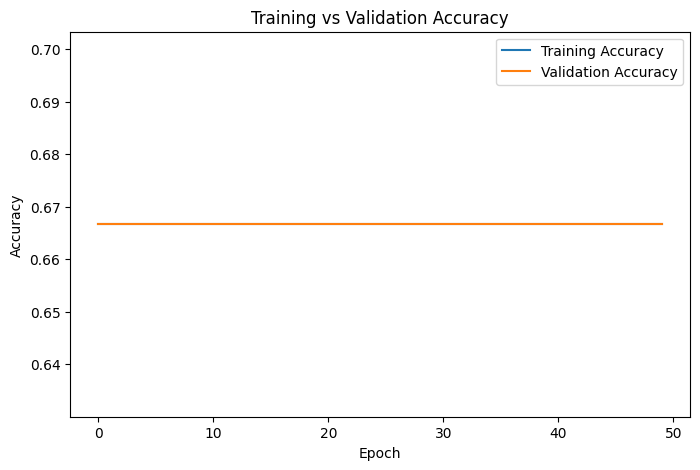

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(X_test)

predicted_classes = (predictions >= 0.5).astype(int)

print("Predicted:", predicted_classes.flatten())
print("Actual:   ", y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted: [1 1 1 1]
Actual:    [0 1 1 1]


In [ ]:
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.75


## 2. PyTorch vs TensorFlow/Keras

The TensorFlow/Keras model was compared with the neural network
implemented previously using PyTorch.

The comparison focuses mainly on test accuracy and the overall
model-building workflow.

### Comparison Results

| Model | Test Accuracy |
|---|---:|
| PyTorch | 70.93% |
| TensorFlow/Keras | 75.00% |

TensorFlow/Keras achieved a slightly higher test accuracy than the previous PyTorch model.

### Conclusion

The TensorFlow/Keras model achieved a test accuracy of 75%, while the previous PyTorch model achieved 70.93%.

Based on test accuracy, the TensorFlow/Keras model performed slightly better on this dataset. However, the difference is relatively small, so the result does not mean that TensorFlow is always better than PyTorch. The two frameworks also provide different approaches for building and training neural networks.